In [6]:
from mipt import *

In [ ]:
x = 4
y = 4
d=4*(x*y)
res = 5
realisations = 5
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_2d(x=x, y=y, d=d, res=res, realisations=realisations, p_min=0.0, p_max=0.5)

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.95, f"x = {x}, y = {y}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, ents, yerr=ent_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.hlines(0, ps[0], ps[-1], colors='black', linestyles='dashed')
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('von Neumann Entropy $S$')
ax2.set_xlabel('Measurement rate $p$')
ax2.set_ylabel('Mutual Information $I$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
plt.tight_layout()

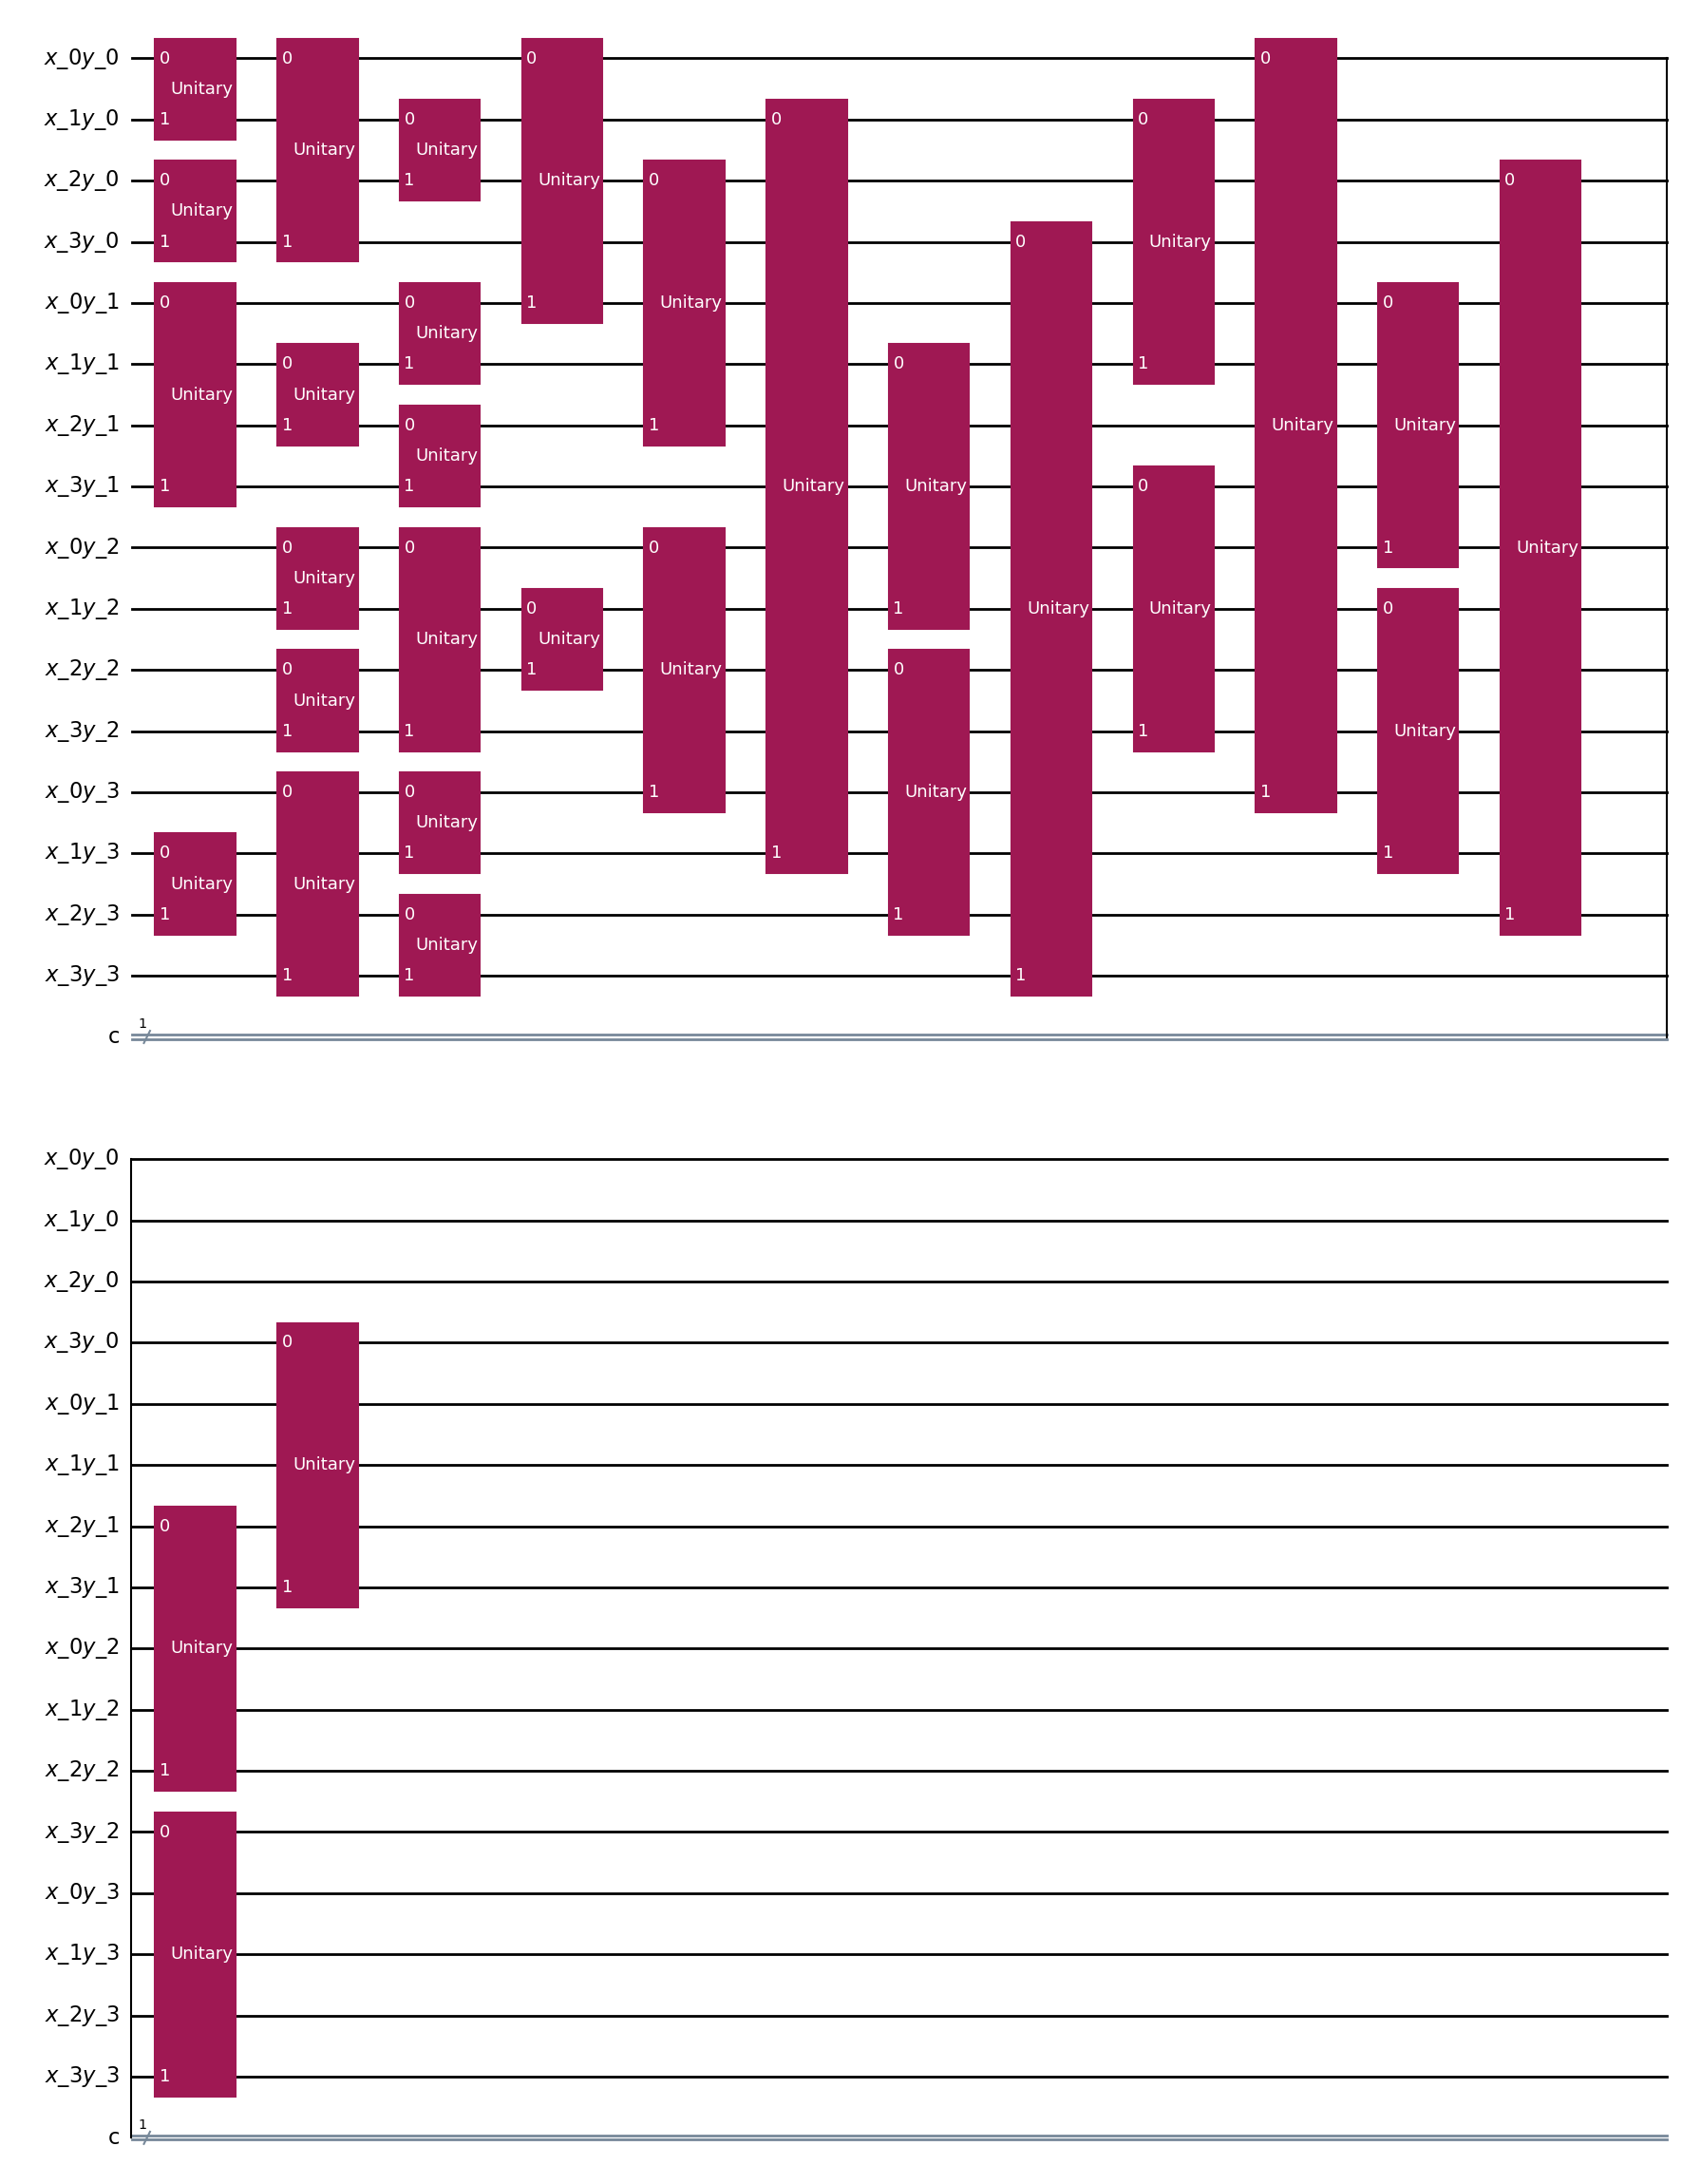

: 

In [ ]:
from mipt import *

qc = random_mipt_2d(x=4, y=4, d=4, p=0)
qc.draw('mpl')
# qc.save_statevector(label='final_state')
# backend = AerSimulator(device='GPU')
# transpiled_qc = transpile(qc, backend)
# result = backend.run(transpiled_qc).result()
# saved_state = result.data(0)['final_state']

# rho = partial_trace(saved_state, [i for i in range(4*4 - 3)])
# print(gmn(rho))

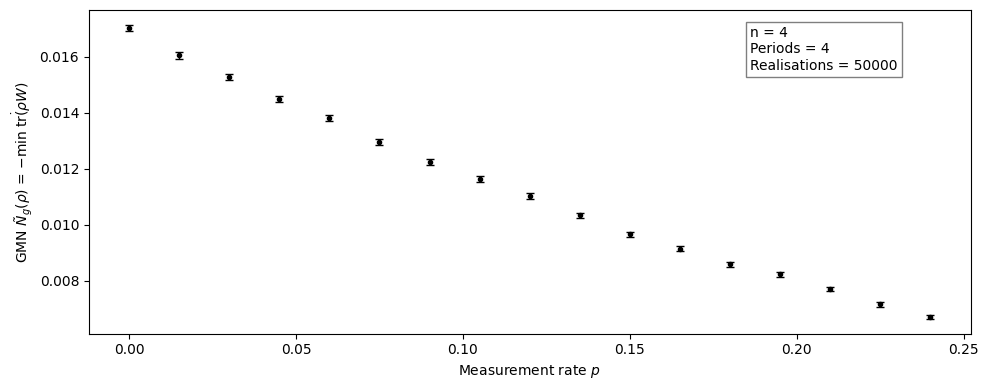

: 

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_csv('data.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
# tmi_values = data_array[1]
gmn_values = data_array[1]

df2 = pd.read_csv('info.csv')
data_array2 = df2.to_numpy().transpose()
n = int(data_array2[0][0])
periods = int(data_array2[1][0])
realizations = int(data_array2[2][0])
res = int(data_array2[3][0])
p_min = float(data_array2[4][0])
p_max = float(data_array2[5][0])

ps_unique = list(set(ps))
# tmi_means = []
# tmi_stds = []
gmn_means = []
gmn_stds = []
for p in ps_unique:
    # tmi_values_for_p = [tmi for tmi, p_val in zip(tmi_values, ps) if p_val == p]
    # tmi_means.append(np.mean(tmi_values_for_p))
    # tmi_stds.append(np.std(tmi_values_for_p)/np.sqrt(realizations))
    gmn_values_for_p = [gmn for gmn, p_val in zip(gmn_values, ps) if p_val == p]
    gmn_means.append(np.mean(gmn_values_for_p))
    gmn_stds.append(np.std(gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
# ax2.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')
# ax2.set_ylabel('GMN')

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.75, 0.95, f"n = {n}\nPeriods = {periods}\nRealisations = {realizations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
 
fig.tight_layout()

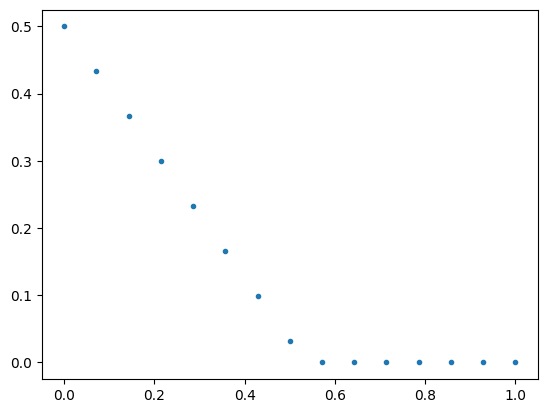

In [2]:
from mipt import *
import numpy as np
from numpy.typing import NDArray
from scipy.optimize import curve_fit

Array = NDArray[np.complex128]

def ghz_white_noise_state(parties: int, p_noise: float) -> np.ndarray:
    """
    rho(p) = (1 - p) |GHZ_n><GHZ_n| + p I / 2**n
    """
    d = 2 ** parties

    psi = np.zeros(d, dtype=np.complex128)
    psi[0] = 1.0 / np.sqrt(2.0)
    psi[-1] = 1.0 / np.sqrt(2.0)

    rho_ghz = np.outer(psi, psi.conj())

    return (1.0 - p_noise) * rho_ghz + p_noise * np.eye(d) / d

ps = np.linspace(0, 1, 15)
gmn_values = []
for p in ps:
    rho = ghz_white_noise_state(parties=4, p_noise=p)
    score = gmn(
            rho,
            parties=4,
            formulation="monotone",
            return_problem=False,
        )
    gmn_values.append(score)

plt.plot(ps, gmn_values, '.')

In [1]:
parties = 4
partitions = {chr(ord('A') + i): [i] for i in range(parties)}
print(partitions.items())

dict_items([('A', [0]), ('B', [1]), ('C', [2]), ('D', [3])])


Simulating p = 0.05
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.1625
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.275
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.3875
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.5
Simulating d = 1
Simulating d = 2
Simulating d = 3


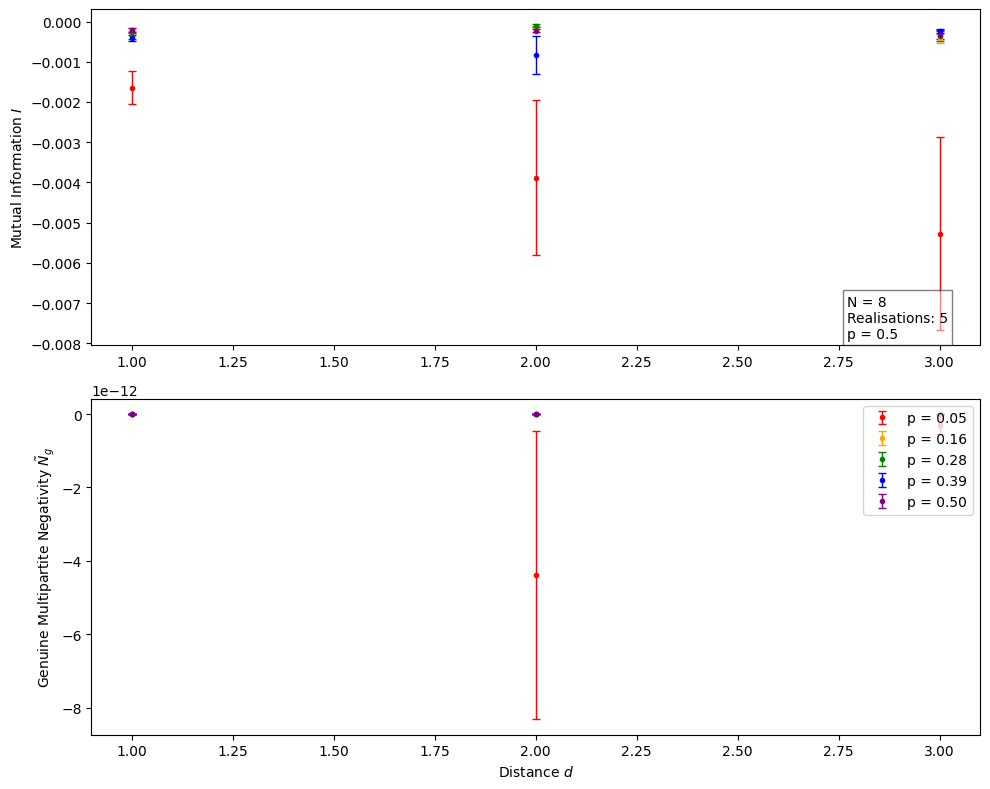

In [4]:
from mipt import *

n = 8
depth = 2*n
ps = np.linspace(0.05, 0.5, 5)
realisations = 5

mi_list, mi_std_list, gmn_list, gmn_std_list = [], [], [], []

for p in ps:
        print("Simulating p =", p)
        d_values, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_1d_distance_scan(
                n, depth, p, realisations, d_min=1, d_max=3, use_gpu=False)

        mi_list.append(mis)
        mi_std_list.append(mi_stds)
        gmn_list.append(gmns)
        gmn_std_list.append(gmn_stds)



fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.15, f"N = {n}\nRealisations: {realisations}\np = {p}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

colors = ["red", "orange", "green", "blue", "purple"]
for i in range(len(ps)):        
        ax1.errorbar(d_values, mi_list[i], yerr=mi_std_list[i], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1)
        ax2.errorbar(d_values, gmn_list[i], yerr=gmn_std_list[i], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1, label= f"p = {ps[i]:.2f}")
# ax3.hlines(0, d_values[0], d_values[-1], colors='black', linestyles='dashed')
ax2.set_xlabel('Distance $d$')
ax1.set_ylabel('Mutual Information $I$')
ax2.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
ax2.legend(loc='upper right')
plt.tight_layout()